# QRT Challenge — Asset Allocation Performance Forecasting

## 1. Context

This challenge is proposed by **Qube Research & Technologies (QRT)**, a global quantitative and systematic investment manager.

---

## 2. What is an Allocation?

An **allocation** is a systematic trading strategy — a portfolio of $M$ assets with weights $w_{S,t,i}$ rebalanced every day.

> `ALLOCATION` is **not** an individual asset (stock, ETF...). It is an **entire portfolio**, potentially long/short, rebalanced daily.

At each day $t$, the weights of an allocation $S$ satisfy:

$$\forall\, t,\ \forall\, S : \quad \sum_{i=1}^{M} |w_{S,t,i}| = 1$$

The **realized return** of allocation $S$ at day $t+1$ is:

$$r_{S,t+1} = \sum_{i=1}^{M} w_{S,t,i} \cdot r_{i,t+1}$$

---

## 3. Data Description

The dataset is a **panel (date × allocation)** — each row corresponds to an allocation $S$ observed at date $t$.

| Column | Description |
|---|---|
| `TS` | Anonymized timestamp (see note below) |
| `ALLOCATION` | Strategy identifier |
| `RET_i` ($i = 1, \ldots, 20$) | Allocation return $i$ days ago |
| `SIGNED_VOLUME_i` ($i = 1, \ldots, 20$) | Signed volume $i$ days ago |
| `MEDIAN_DAILY_TURNOVER` | Median daily turnover over 20 days |
| `GROUP` | Anonymized allocation group |
| `target` | **Next day** allocation return (target variable) |

### Signed Volume

$$V_{S,t} = \sum_{i=1}^{M} w_{S,t,i} \cdot V_{i,t}$$

### Median Daily Turnover

$$TO_{S,t} = \sum_{i=1}^{M} |w_{S,t,i} - w_{S,t-1,i}|$$

$$MDT_{S,t} = \text{median}(TO_{S,t},\ TO_{S,t-1},\ \ldots,\ TO_{S,t-20})$$

---

## 4. Objective

For each row $(t, S)$, predict the **sign of the next day return**:

$$\hat{y}_i = \begin{cases} 1 & \text{if } r_{S,t+1} > 0 \quad \text{(follow the allocation — go long)} \\ 0 & \text{if } r_{S,t+1} \leq 0 \quad \text{(short the allocation)} \end{cases}$$

---

## 5. Evaluation Metric

$$\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}\left[\text{sign}(\hat{r}_i) = \text{sign}(r_i)\right]$$

$$= \frac{1}{T \cdot M} \sum_{t=1}^{T} \sum_{S=1}^{M} \mathbf{1}\left[\text{sign}(\hat{r}_{S,t+1}) = \text{sign}(r_{S,t+1})\right]$$

The provided LightGBM benchmark achieves **50.79%** on the public leaderboard.

---

## 6. Key Remarks

> **Dates are anonymized and shuffled.** There is no guarantee that `DATE_0002` follows `DATE_0001` in real time. This implies:
> - **Lag features across consecutive rows are invalid**
> - The only reliable features are **intra-row** (based on the 20-day history provided) and **cross-sectional by date** (comparing allocations at the same timestamp $t$)
> - A **standard KFold** is as valid as a temporal split since the chronological order of dates is not guaranteed

### Panel Structure

$$\underbrace{511}_{\text{dates}} \times \underbrace{278}_{\text{max allocations}} \approx \underbrace{105\,000}_{\text{rows (20\% sample)}}$$

On average **206 allocations per date**, with a minimum of 65 on the earliest dates.

In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
from models.preparing import Dataset
from models.modeling import ModelTrainer
from models.visualizing import ModelVisualizer

# ── 1. Load sample ───────────────────────────────────────────────────────────
df = pd.read_csv('../data/sample.csv')
print(df.shape)
print(df.columns.tolist())


(105414, 45)
['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP', 'target']


In [2]:
df

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1,0.009210
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4,0.000405
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1,0.005967
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2,-0.000542
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4,-0.002579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105409,DATE_0511,ALLOCATION_22,0.001852,0.001607,-0.000801,0.000385,0.002574,0.002541,0.001580,0.004665,...,-2.671094,-2.080118,-1.406784,-1.625861,-1.516261,-1.437714,NaN,0.218876,4,0.001965
105410,DATE_0511,ALLOCATION_220,0.000457,0.000173,-0.004411,0.001285,0.003893,0.001032,-0.003360,-0.006239,...,1.363651,1.578637,1.712677,1.456396,0.947003,0.976735,NaN,0.008265,4,-0.001427
105411,DATE_0511,ALLOCATION_221,0.002675,-0.004693,0.002126,-0.002589,-0.001454,0.000403,-0.004247,-0.001243,...,1.627571,1.298646,1.594538,1.293960,1.013300,1.063698,NaN,0.000440,3,0.007087
105412,DATE_0511,ALLOCATION_222,-0.003010,-0.000338,0.000084,0.000950,-0.000939,-0.003073,-0.000226,-0.002958,...,0.283108,1.090673,1.079742,1.624748,1.886851,1.153242,0.847115,0.155893,2,-0.003715


In [3]:
# ── Missing Values Analysis ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)
print(f"\nTotal rows: {len(df)}")
print(f"Total columns with missing values: {len(missing_df)}")

                       Missing Count  Missing %
SIGNED_VOLUME_1                76763      72.82
SIGNED_VOLUME_20                1252       1.19
MEDIAN_DAILY_TURNOVER            685       0.65
SIGNED_VOLUME_19                 405       0.38
SIGNED_VOLUME_18                 191       0.18
SIGNED_VOLUME_15                   6       0.01
RET_19                             8       0.01
RET_18                             6       0.01
SIGNED_VOLUME_14                   6       0.01
SIGNED_VOLUME_16                   8       0.01
SIGNED_VOLUME_17                   8       0.01
RET_20                             8       0.01
RET_17                             6       0.01
RET_16                             5       0.00
RET_14                             4       0.00
RET_12                             2       0.00
SIGNED_VOLUME_13                   5       0.00
SIGNED_VOLUME_12                   4       0.00
SIGNED_VOLUME_11                   4       0.00
SIGNED_VOLUME_10                   4    

In [4]:
# Est-ce que les missing de SIGNED_VOLUME_1 sont aléatoires ou structurels ?
print("Missing SIGNED_VOLUME_1 par GROUP:")
print(df[df['SIGNED_VOLUME_1'].isna()]['GROUP'].value_counts())

print("\nMissing SIGNED_VOLUME_1 par date (top 10):")
print(df[df['SIGNED_VOLUME_1'].isna()]['TS'].value_counts().head(10))

print("\nQuand SIGNED_VOLUME_1 est missing, SIGNED_VOLUME_2 est-il présent ?")
mask = df['SIGNED_VOLUME_1'].isna()
print(df[mask]['SIGNED_VOLUME_2'].isna().value_counts())

Missing SIGNED_VOLUME_1 par GROUP:
GROUP
3    24891
2    19257
4    17798
1    14817
Name: count, dtype: int64

Missing SIGNED_VOLUME_1 par date (top 10):
TS
DATE_0001    252
DATE_0002    252
DATE_0005    252
DATE_0007    252
DATE_0010    252
DATE_0014    252
DATE_0015    252
DATE_0016    252
DATE_0019    252
DATE_0023    252
Name: count, dtype: int64

Quand SIGNED_VOLUME_1 est missing, SIGNED_VOLUME_2 est-il présent ?
SIGNED_VOLUME_2
False    76763
Name: count, dtype: int64


### Missing Values Analysis

23 columns contain missing values. Two distinct patterns emerge:

**Structural missing — `SIGNED_VOLUME_1` (72.82%)**
The most recent signed volume is missing for 76,763 observations. 
Crucially, this missingness is date-level: on affected dates, 
all allocations simultaneously have no `SIGNED_VOLUME_1` value, 
while `SIGNED_VOLUME_2` remains always available.
This is consistent with a data collection constraint — 
the signed volume of the most recent trading session may not be 
consolidated at the time the snapshot is taken.
The missing values are distributed proportionally across all groups, 
confirming the absence of any group-specific bias.

**Negligible missing — other columns (< 1.2%)**
All remaining columns with missing values affect fewer than 1,252 rows (< 1.2%), 
with most below 0.01%. These are treated as random and imputed with zero (of forward fill.. that is treated by our modeule), 


In [5]:
df.groupby('TS')['ALLOCATION'].count()

TS
DATE_0001    276
DATE_0002    276
DATE_0003     69
DATE_0004    204
DATE_0005    276
            ... 
DATE_0507    140
DATE_0508    276
DATE_0509    276
DATE_0510    276
DATE_0511    145
Name: ALLOCATION, Length: 511, dtype: int64

In [6]:
df[df['TS'] == 'DATE_0003']

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,target
552,DATE_0003,ALLOCATION_08,0.000586,-0.001710,-0.017752,0.005784,0.009490,0.003056,-0.016739,-0.011237,...,0.568812,1.057861,0.841778,0.581410,0.779497,0.812851,NaN,0.006829,3,0.006587
553,DATE_0003,ALLOCATION_09,-0.002975,-0.004082,0.000276,0.000591,0.001475,-0.000580,0.000745,-0.000635,...,-1.676179,-2.738400,-1.405094,-1.039547,-0.687777,-1.309714,NaN,0.027125,3,-0.005584
554,DATE_0003,ALLOCATION_101,-0.000484,-0.003274,-0.002881,0.002886,0.005493,-0.000954,0.003236,0.001505,...,1.046086,1.323018,1.007600,0.717361,0.702671,0.825296,NaN,0.002488,3,0.004354
555,DATE_0003,ALLOCATION_103,-0.001420,-0.000778,-0.004168,0.001146,0.003759,-0.001720,0.002113,0.001504,...,1.001544,1.306691,0.987030,0.743375,0.684693,0.886094,NaN,0.007387,3,0.004228
556,DATE_0003,ALLOCATION_104,-0.005128,-0.002953,0.000713,0.000559,-0.000329,0.000448,-0.001770,-0.004496,...,-0.257244,-0.248380,-0.943467,-1.104779,-0.923865,-0.800104,NaN,0.000495,3,-0.005484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
616,DATE_0003,ALLOCATION_88,-0.003496,-0.001385,-0.002740,0.005597,-0.001917,0.002729,-0.005670,-0.002648,...,-5.217344,-7.425409,-2.803067,-1.198172,-0.850989,-2.438857,NaN,0.006721,3,-0.002207
617,DATE_0003,ALLOCATION_90,-0.000745,0.001409,-0.001639,-0.001172,-0.001647,0.000175,0.002885,0.005094,...,1.006802,1.306498,1.010705,0.753713,0.765591,0.940100,NaN,0.005458,3,0.007062
618,DATE_0003,ALLOCATION_93,-0.005995,-0.001515,-0.008638,0.008276,0.002876,0.004351,0.003547,-0.000257,...,-0.496047,-0.366504,-1.392268,-1.177930,-0.859735,-0.947209,NaN,0.014254,3,0.005816
619,DATE_0003,ALLOCATION_96,-0.007302,0.000050,-0.004291,0.008650,-0.000389,0.009829,-0.003046,-0.003024,...,-0.158805,-0.004012,-1.085601,-1.279054,-0.522326,-1.200330,NaN,0.005216,3,-0.002369


In [7]:
## EDA:

# Combien de groupes ?
print(df['GROUP'].value_counts())

# Distribution du target par groupe
print(df.groupby('GROUP')['target'].apply(lambda x: (x > 0).mean()))

GROUP
3    34385
2    26442
4    24461
1    20126
Name: count, dtype: int64
GROUP
1    0.492795
2    0.517623
3    0.507140
4    0.516741
Name: target, dtype: float64


In [8]:
# Win rate moyen par allocation (les meilleures stratégies)
win_rate = df.groupby('ALLOCATION')['target'].apply(lambda x: (x > 0).mean())
print(win_rate.describe())
print(win_rate.sort_values(ascending=False).head(10))

count    278.000000
mean       0.507708
std        0.036043
min        0.371968
25%        0.486205
50%        0.507042
75%        0.528114
max        0.661972
Name: target, dtype: float64
ALLOCATION
ALLOCATION_152    0.661972
ALLOCATION_187    0.656992
ALLOCATION_31     0.648649
ALLOCATION_266    0.591892
ALLOCATION_22     0.590296
ALLOCATION_118    0.585513
ALLOCATION_06     0.579861
ALLOCATION_126    0.572559
ALLOCATION_269    0.571429
ALLOCATION_189    0.569921
Name: target, dtype: float64


## Key Observations

### Group-level analysis
The 4 groups exhibit slightly different win rates, with **Group 2 being the most profitable** (51.76%) 
and **Group 1 being the only one below 50%** (49.28%). This suggests that `GROUP` carries 
structural information about the allocation style and should be treated as a relevant feature.

### Allocation-level analysis
Individual allocations show significant dispersion in win rates (std = 3.6%), ranging from **37.2% to 66.2%**. 
This indicates that some allocations are structurally more profitable than others, independently of market conditions — 
a signal that allocation identity itself carries predictive value.

### Implications for feature engineering
- `GROUP` should be retained as a categorical feature
- Cross-sectional features comparing allocations at the same timestamp remain the most reliable approach, 
given that date continuity is not guaranteed in this dataset

count    105414.000000
mean          0.000064
std           0.003126
min          -0.041115
25%          -0.001489
50%           0.000053
75%           0.001614
max           0.046153
Name: target, dtype: float64

Win rate global : 0.5093


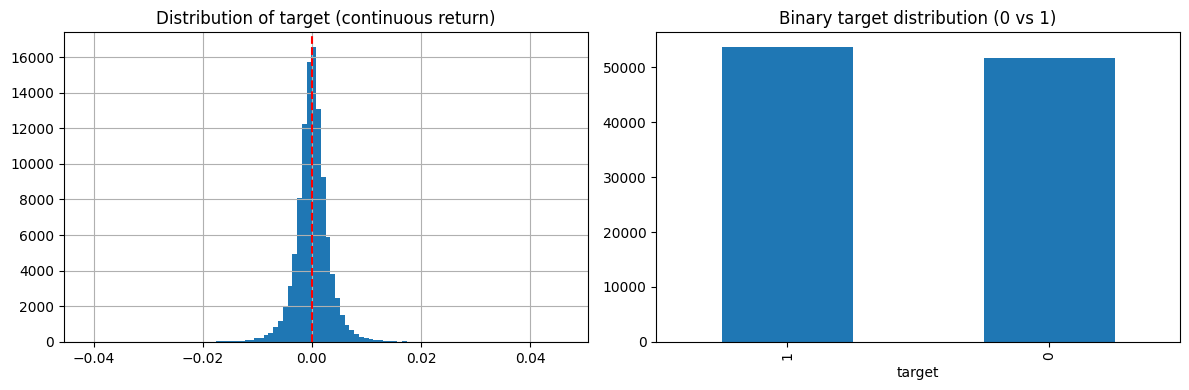

In [9]:
# ── Exploration 1 : Distribution du target ──────────────────────────────────
print(df['target'].describe())
print(f"\nWin rate global : {(df['target'] > 0).mean():.4f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['target'].hist(bins=100, ax=axes[0])
axes[0].set_title('Distribution of target (continuous return)')
axes[0].axvline(0, color='red', linestyle='--')

(df['target'] > 0).astype(int).value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Binary target distribution (0 vs 1)')
plt.tight_layout()
plt.show()

In [10]:
# ── Exploration 2 : Est-ce que RET_1 prédit le target ? ─────────────────────
# (momentum vs mean-reversion)
import numpy as np

bins = pd.qcut(df['RET_1'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
print(df.groupby(bins)['target'].apply(lambda x: (x > 0).mean()))

RET_1
Q1    0.484656
Q2    0.491533
Q3    0.509107
Q4    0.520372
Q5    0.540625
Name: target, dtype: float64


RET_1     0.099772
RET_2    -0.018947
RET_3    -0.006710
RET_4    -0.036109
RET_5    -0.002830
RET_6     0.035748
RET_7     0.042723
RET_8     0.027782
RET_9     0.014946
RET_10   -0.015815
RET_11    0.010332
RET_12    0.015396
RET_13    0.008196
RET_14    0.012819
RET_15    0.013437
RET_16   -0.012695
RET_17    0.052525
RET_18   -0.010773
RET_19    0.007957
RET_20    0.013763
Name: target, dtype: float64


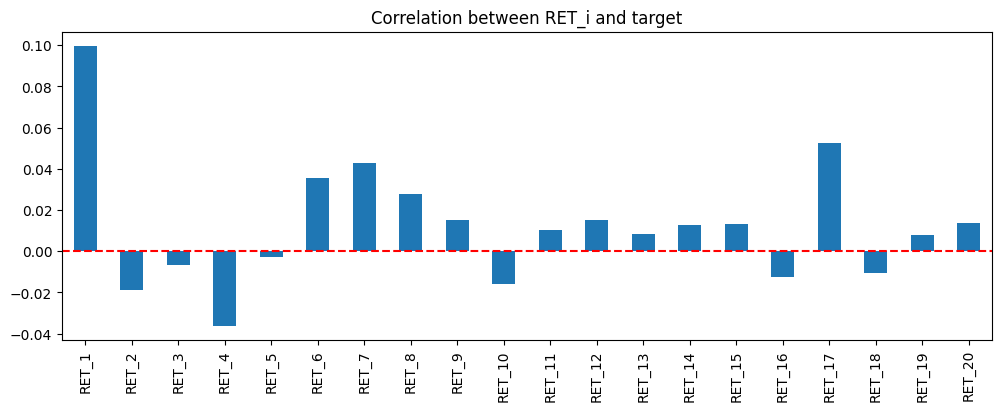

In [11]:
# ── Exploration 3 : Corrélation entre RET_i et target ───────────────────────
# Voit-on du momentum (RET récent corrélé positivement) ou mean-reversion ?
RET_features = [f'RET_{i}' for i in range(1, 21)]
corrs = df[RET_features + ['target']].corr()['target'][:-1]
print(corrs)

corrs.plot(kind='bar', figsize=(12, 4), title='Correlation between RET_i and target')
plt.axhline(0, color='red', linestyle='--')
plt.show()

SIGNED_VOLUME_1     0.000905
SIGNED_VOLUME_2    -0.005462
SIGNED_VOLUME_3    -0.010311
SIGNED_VOLUME_4    -0.017128
SIGNED_VOLUME_5    -0.017661
SIGNED_VOLUME_6    -0.008920
SIGNED_VOLUME_7    -0.009000
SIGNED_VOLUME_8    -0.014181
SIGNED_VOLUME_9    -0.013977
SIGNED_VOLUME_10   -0.010890
SIGNED_VOLUME_11   -0.016578
SIGNED_VOLUME_12   -0.007812
SIGNED_VOLUME_13   -0.012974
SIGNED_VOLUME_14   -0.001975
SIGNED_VOLUME_15   -0.003748
SIGNED_VOLUME_16   -0.004715
SIGNED_VOLUME_17    0.004268
SIGNED_VOLUME_18   -0.008769
SIGNED_VOLUME_19   -0.013767
SIGNED_VOLUME_20    0.000925
Name: target, dtype: float64


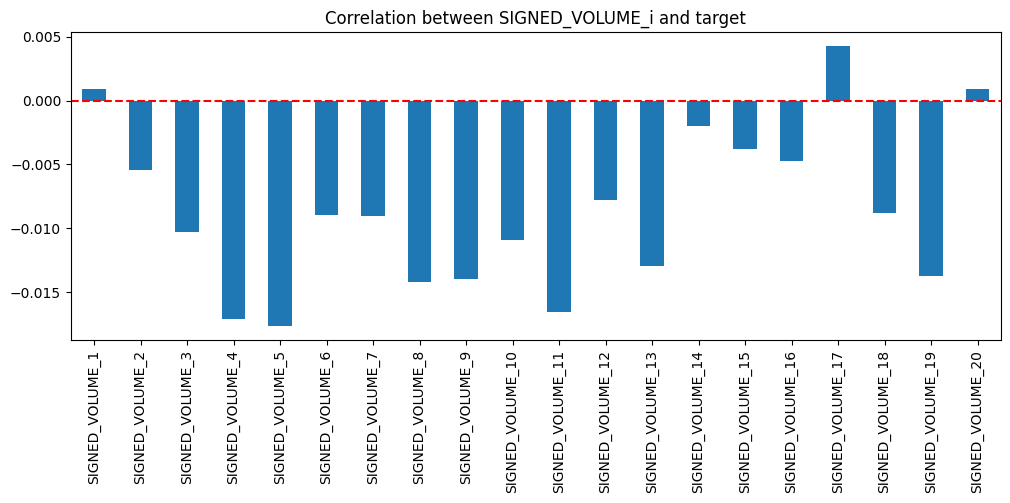

In [12]:
# ── Exploration 4 : SIGNED_VOLUME prédit-il le target ? ─────────────────────
SVOL_features = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]
corrs_vol = df[SVOL_features + ['target']].corr()['target'][:-1]
print(corrs_vol)

corrs_vol.plot(kind='bar', figsize=(12, 4), title='Correlation between SIGNED_VOLUME_i and target')
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [13]:
# ── Exploration 5 : TURNOVER et target ──────────────────────────────────────
# Les stratégies à fort turnover sont-elles plus prévisibles ?
bins_to = pd.qcut(df['MEDIAN_DAILY_TURNOVER'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
print(df.groupby(bins_to)['target'].apply(lambda x: (x > 0).mean()))
print(df.groupby(bins_to)['target'].std())

MEDIAN_DAILY_TURNOVER
Q1    0.502817
Q2    0.505061
Q3    0.509811
Q4    0.506923
Q5    0.521866
Name: target, dtype: float64
MEDIAN_DAILY_TURNOVER
Q1    0.003160
Q2    0.003050
Q3    0.002926
Q4    0.003207
Q5    0.003074
Name: target, dtype: float64


In [14]:
# ── Exploration 6 : Volatilité récente et target ────────────────────────────
# Une allocation volatile récemment est-elle plus ou moins prévisible ?
df['VOL_5']  = df[RET_features[:5]].std(axis=1)
df['VOL_20'] = df[RET_features].std(axis=1)

bins_vol = pd.qcut(df['VOL_5'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
print("Win rate by recent volatility quintile:")
print(df.groupby(bins_vol)['target'].apply(lambda x: (x > 0).mean()))

Win rate by recent volatility quintile:
VOL_5
Q1    0.500498
Q2    0.501067
Q3    0.510009
Q4    0.508656
Q5    0.526064
Name: target, dtype: float64


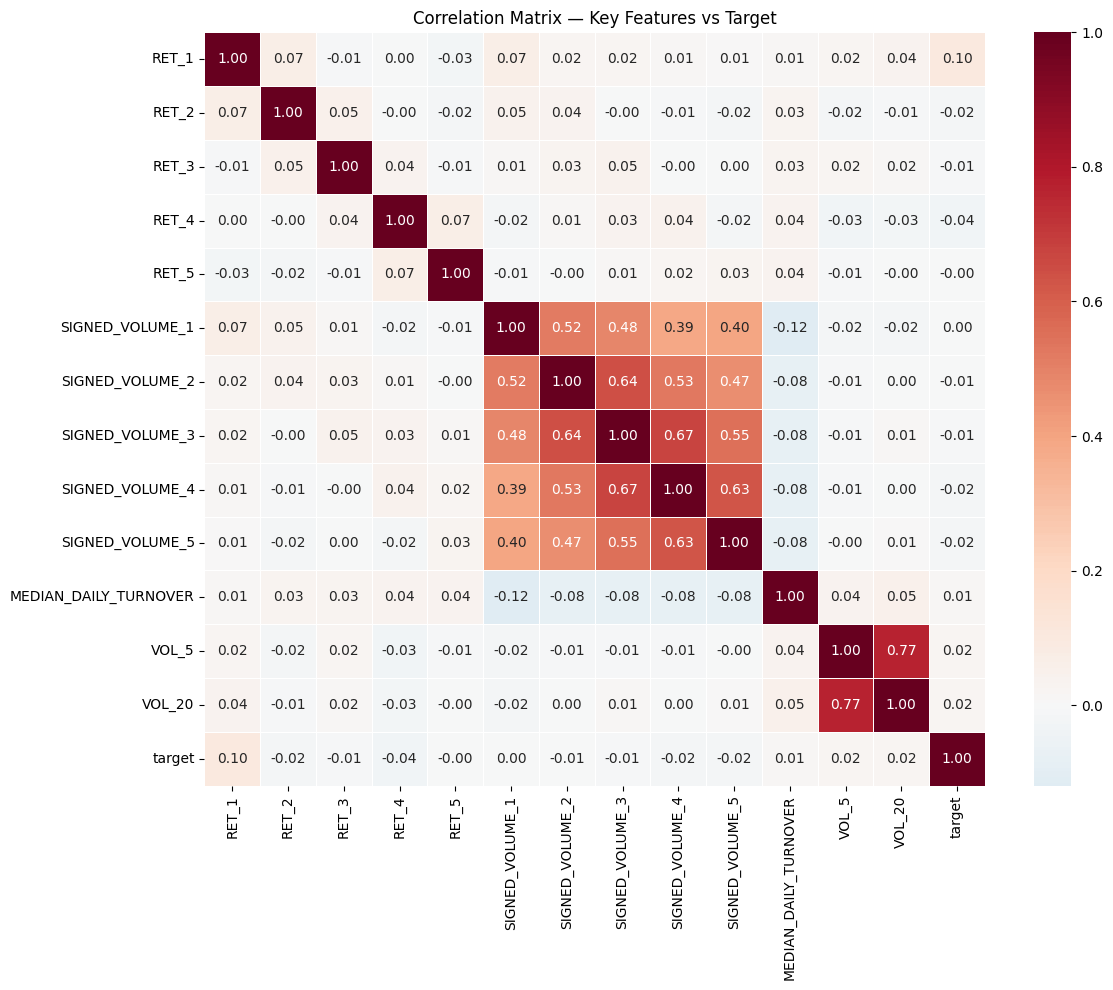

In [15]:
# ── Heatmap de corrélation ───────────────────────────────────────────────────
import seaborn as sns

# On prend les features les plus importantes + target
cols_to_plot = (
    [f'RET_{i}' for i in range(1, 6)]
    + [f'SIGNED_VOLUME_{i}' for i in range(1, 6)]
    + ['MEDIAN_DAILY_TURNOVER', 'VOL_5', 'VOL_20', 'target']
)

corr = df[cols_to_plot].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
)
plt.title('Correlation Matrix — Key Features vs Target')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis — Summary & Feature Engineering Justification

### EDA 1 — Target Distribution
The target is a continuous return, approximately symmetric around zero (mean ≈ 0.000064, std ≈ 0.003).
The global win rate is **50.93%**, confirming that the binary classification problem is nearly balanced.
The distribution is leptokurtic (fat tails), which is characteristic of financial return series.

### EDA 2 & 3 — Return History vs Target
Binning allocations by `RET_1` quintiles reveals a clear **momentum effect at lag 1**:
allocations that performed well yesterday (Q5) have a win rate of **54.06%**, 
while the worst performers (Q1) show only **48.47%**.

The full correlation analysis across all 20 lags confirms this pattern:

| Lag | Correlation | Interpretation |
|-----|-------------|----------------|
| RET_1 | +0.0998 | Strong short-term momentum |
| RET_2 | -0.0189 | Mild mean-reversion |
| RET_4 | -0.0361 | Mean-reversion at J-4 |
| RET_17 | +0.0525 | Longer-term momentum |

**Justification**: this motivates the construction of short-term momentum features 
(e.g. cumulative return over 1-3 days) and mean-reversion features (e.g. deviation 
from recent average).

### EDA 4 — Signed Volume vs Target
Signed volume correlations with the target are **predominantly negative**, 
particularly at lags 4 and 5. This indicates that when the market trades heavily 
in the direction of the strategy, a **mean-reversion** tends to follow the next day.


**Justification**: this motivates volume-based features capturing the recent 
directional pressure of market flows relative to the allocation.

### EDA 5 — Turnover vs Target
Allocations in the highest turnover quintile (Q5) achieve a win rate of **52.19%**, 
compared to **50.28%** for the lowest quintile (Q1). High-turnover strategies 
react faster to market signals, making their short-term momentum more predictable.

**Justification**: `MEDIAN_DAILY_TURNOVER` should be retained as a feature, 
and may also be used to construct interaction features with return signals.

### EDA 6 — Recent Volatility vs Target
Allocations with high recent volatility (Q5) achieve a win rate of **52.61%**, 
versus **50.05%** for the least volatile (Q1). This suggests that when a strategy 
moves significantly, its directional signal is stronger and more exploitable.

**Justification**: this motivates the construction of rolling volatility features 
over short windows (e.g. 5 and 20 days).

---


### EDA 7 — Correlation Matrix

Several structural patterns emerge from the correlation matrix:

**Return features vs target**
- `RET_1` is the only return feature with a meaningful correlation with the target (+0.10),
confirming the short-term momentum effect identified in EDA 2 and 3.
- `RET_2` to `RET_5` show negligible or slightly negative correlations, consistent 
with the mild mean-reversion pattern observed at short lags.

**Signed volume features**
- The signed volume features are **highly correlated with each other** 
(e.g. `SIGNED_VOLUME_2` and `SIGNED_VOLUME_3` at 0.64), suggesting that market 
flow direction is persistent over several days.
- However, their individual correlations with the target are close to zero, 
confirming that raw signed volume alone is not a strong predictor — 
its interaction with returns may be more informative.
- `MEDIAN_DAILY_TURNOVER` is **negatively correlated with signed volume** (~-0.08 to -0.12), 
suggesting that high-turnover strategies trade against prevailing market flows.

**Volatility features**
- `VOL_5` and `VOL_20` are strongly correlated (0.77), as expected — 
short-term volatility is embedded in long-term volatility.
- Both show low but positive correlation with the target (+0.02), 
consistent with EDA 6: more volatile allocations are slightly more predictable.

**Key takeaway for feature engineering**
The dominant predictive signal is `RET_1`. Volume features contribute through 
interaction effects rather than direct linear relationships. 
Volatility features add marginal but consistent signal.


## Feature Engineering Plan

Based on the above findings, we will construct the following features:

**Momentum features**
- Short-term cumulative return: sum of `RET_1`, `RET_2`, `RET_3`
- Medium-term cumulative return: sum of `RET_1` to `RET_5`
- Momentum vs mean-reversion: `RET_1` minus average of `RET_2` to `RET_5`
- Sharpe ratio over 5 days: mean of `RET_1` to `RET_5` divided by their standard deviation

**Volatility features**
- Rolling volatility over 5 days: std of `RET_1` to `RET_5`
- Rolling volatility over 20 days: std of `RET_1` to `RET_20`
- Volatility ratio: `VOL_5 / VOL_20` (recent vs long-term regime)

**Volume features**
- Short-term signed volume: sum of `SIGNED_VOLUME_2` to `SIGNED_VOLUME_4`
- Volume-return interaction: `RET_1 * SIGNED_VOLUME_2` (conviction signal)

> Note: `SIGNED_VOLUME_1` is excluded due to 72.82% missing values. 
> This missingness is date-level and structural, making imputation unreliable.

**Cross-sectional features** (computed within each timestamp `TS`)
- Cross-sectional rank of `RET_1` among all allocations at the same date
- Cross-sectional rank of `VOL_5` among all allocations at the same date
- Cross-sectional mean and std of `RET_1` per `GROUP` and date

**Structural features**
- `GROUP` as a categorical feature
- `MEDIAN_DAILY_TURNOVER` as a continuous feature

In [16]:
# ── Feature Engineering ──────────────────────────────────────────────────────

RET_features  = [f'RET_{i}'  for i in range(1, 21)]
SVOL_features = [f'SIGNED_VOLUME_{i}' for i in range(2, 21)]  # SIGNED_VOLUME_1 dropped

for i in [3, 5, 10, 15, 20]:
    df[f'AVERAGE_PERF_{i}']             = df[RET_features[:i]].mean(axis=1)
    df[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')

for i in [20]:
    df[f'STD_PERF_{i}']             = df[RET_features[:i]].std(axis=1)
    df[f'ALLOCATIONS_STD_PERF_{i}'] = df.groupby('TS')[f'STD_PERF_{i}'].transform('mean')
# ── Momentum features ────────────────────────────────────────────────────────
df['MOM_3']  = df[['RET_1', 'RET_2', 'RET_3']].sum(axis=1)
df['MOM_5']  = df[[f'RET_{i}' for i in range(1, 6)]].sum(axis=1)
df['MOM_vs_MEAN'] = df['RET_1'] - df[[f'RET_{i}' for i in range(2, 6)]].mean(axis=1)

# Sharpe ratio over 5 days
ret_5 = df[[f'RET_{i}' for i in range(1, 6)]]
df['SHARPE_5'] = ret_5.mean(axis=1) / (ret_5.std(axis=1) + 1e-8)  # 1e-8 pour éviter division par zéro

# ── Volatility features ──────────────────────────────────────────────────────
df['VOL_5']  = df[[f'RET_{i}' for i in range(1, 6)]].std(axis=1)
df['VOL_20'] = df[RET_features].std(axis=1)
df['VOL_RATIO'] = df['VOL_5'] / (df['VOL_20'] + 1e-8)

# ── Volume features ──────────────────────────────────────────────────────────
df['SVOL_SHORT'] = df[[f'SIGNED_VOLUME_{i}' for i in range(2, 5)]].sum(axis=1)
df['CONVICTION'] = df['RET_1'] * df['SIGNED_VOLUME_2']

# ── Cross-sectional features ─────────────────────────────────────────────────
df['CS_RANK_RET1']  = df.groupby('TS')['RET_1'].rank(pct=True)
df['CS_RANK_VOL5']  = df.groupby('TS')['VOL_5'].rank(pct=True)

df['CS_GROUP_MEAN_RET1'] = df.groupby(['TS', 'GROUP'])['RET_1'].transform('mean')
df['CS_GROUP_STD_RET1']  = df.groupby(['TS', 'GROUP'])['RET_1'].transform('std')

# Rank au sein du même GROUP et de la même date
df['CS_GROUP_RANK_RET1'] = df.groupby(['TS', 'GROUP'])['RET_1'].rank(pct=True)
df['CS_GROUP_RANK_VOL5'] = df.groupby(['TS', 'GROUP'])['VOL_5'].rank(pct=True)

print("Features created successfully.")
print(f"Total columns: {df.shape[1]}")

Features created successfully.
Total columns: 72


In [17]:
# ── Liste finale des features ─────────────────────────────────────────────────
features = (
    RET_features
    + SVOL_features
    + ['MEDIAN_DAILY_TURNOVER', 'GROUP']
    # Benchmark features
    + [f'AVERAGE_PERF_{i}'             for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
    + [f'STD_PERF_{i}'                 for i in [20]]
    + [f'ALLOCATIONS_STD_PERF_{i}'     for i in [20]]
    # New features
    + ['MOM_3', 'MOM_5', 'MOM_vs_MEAN', 'SHARPE_5']
    + ['VOL_5', 'VOL_20', 'VOL_RATIO']
    + ['SVOL_SHORT', 'CONVICTION']
    + ['CS_RANK_RET1', 'CS_RANK_VOL5']
    + ['CS_GROUP_MEAN_RET1', 'CS_GROUP_STD_RET1']
    + ['CS_GROUP_RANK_RET1', 'CS_GROUP_RANK_VOL5']
)

print(f"{len(features)} features total")

68 features total


In [18]:
print(df.groupby('TS')['ALLOCATION'].count().describe())
print(df['ALLOCATION'].nunique())
print(df['TS'].nunique())

count    511.000000
mean     206.289628
std       83.771130
min       65.000000
25%      139.000000
50%      210.000000
75%      276.000000
max      276.000000
Name: ALLOCATION, dtype: float64
278
511


In [19]:
df.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP',
       'target', 'VOL_5', 'VOL_20', 'AVERAGE_PERF_3',
       'ALLOCATIONS_AVERAGE_PERF_3', 'AVERAGE_PERF_5',
       'ALLOCATIONS_AVERAGE_PERF_5', 'AVERAGE_PERF_10',
       'ALLOCATIONS_AVERAGE_PERF_10', 'AVERAGE_PERF_15',
       'ALLOCATIONS_AVERAGE_PERF_15', 'AVERAGE_PERF_20',
       'ALLOCAT

In [20]:
missing_features = [f for f in features if f not in df.columns]
print(f"{len(missing_features)} features manquantes:")
print(missing_features)

0 features manquantes:
[]


In [21]:
# ── 3. Préparer le Dataset ───────────────────────────────────────────────────
# Target binaire (classification)
df['target_clf'] = (df['target'] > 0).astype(int)
# Avant de créer le Dataset, ajoute une colonne datetime réelle 
# car les TS de base sont de la forme DATE_0001, Date_0002, etc.
df['date'] = pd.to_datetime(df['TS'].str.extract(r'(\d+)')[0].astype(int), 
                             unit='D', origin='2020-01-01') ## on s'en fout de la date exacte, juste besoin d'une progression temporelle

ds = Dataset(
    data=df,
    target='target_clf',
    features=features,
    timestamp_col='date',  # ← utilise la vraie colonne datetime
)


ds.prepare_dataset(
    test_size=0.2,
    shuffle=False,        # IMPORTANT : pas de shuffle sur données temporelles
    scale_numeric=False,
)

print("X_train:", ds.splits.X_train.shape)
print("X_test: ", ds.splits.X_test.shape)

X_train: (84331, 68)
X_test:  (21083, 68)


In [22]:
ds

In [23]:
ds.splits.X_train

,num__RET_1,num__RET_2,num__RET_3,num__RET_4,num__RET_5,num__RET_6,num__RET_7,num__RET_8,num__RET_9,num__RET_10,...,num__VOL_20,num__VOL_RATIO,num__SVOL_SHORT,num__CONVICTION,num__CS_RANK_RET1,num__CS_RANK_VOL5,num__CS_GROUP_MEAN_RET1,num__CS_GROUP_STD_RET1,num__CS_GROUP_RANK_RET1,num__CS_GROUP_RANK_VOL5
0,0.003944,-0.000178,0.001013,0.001514,-0.009067,0.002864,-0.009116,0.003312,0.001350,-0.009898,...,0.005911,0.844111,0.669370,-0.000865,0.989130,0.927536,-0.000199,0.001452,0.985714,0.971429
175,-0.000461,-0.001194,0.000752,-0.001486,-0.005296,0.002516,-0.003338,0.000168,0.001152,-0.004506,...,0.002447,0.928465,2.334143,-0.000278,0.423913,0.615942,-0.000199,0.001452,0.500000,0.800000
176,-0.000944,-0.002020,-0.002637,-0.000598,-0.005207,0.004702,-0.008985,-0.000142,0.007539,-0.004474,...,0.006136,0.298007,2.300225,-0.000634,0.304348,0.438406,-0.000199,0.001452,0.257143,0.585714
177,-0.000125,-0.001329,0.000693,0.001745,-0.000442,0.002631,-0.000861,0.000837,-0.000103,0.000714,...,0.001227,0.951042,-3.376836,0.000124,0.496377,0.170290,-0.000036,0.001162,0.393939,0.318182
178,0.000217,-0.002302,-0.000962,-0.003306,-0.002930,0.000621,-0.001118,0.001306,0.001724,-0.003843,...,0.002363,0.618666,2.212515,0.000063,0.619565,0.278986,-0.000199,0.001452,0.614286,0.442857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84405,0.002336,-0.000162,0.009772,0.003397,-0.006838,0.003745,-0.001177,-0.011920,-0.000473,0.004145,...,0.006987,0.861183,2.486738,0.001078,0.818627,0.960784,0.000605,0.002991,0.739130,0.956522
84406,0.001434,-0.003616,0.000972,-0.002775,-0.003213,0.001284,0.000269,-0.000261,-0.007705,0.003006,...,0.002687,0.906763,1.908947,0.000094,0.705882,0.465686,0.000605,0.002991,0.565217,0.405797
84407,-0.001873,-0.005669,-0.003129,0.005421,-0.000814,-0.007441,0.002380,-0.001820,-0.002328,-0.001627,...,0.003858,1.069780,2.166728,0.000303,0.186275,0.799020,-0.000629,0.002947,0.318841,0.608696
84408,-0.000173,-0.002299,0.001124,-0.000721,0.000016,0.002837,-0.001971,-0.001940,0.001022,-0.003923,...,0.002121,0.589730,-3.346554,0.000261,0.455882,0.132353,0.000275,0.001468,0.469697,0.272727


## 4. Modeling

### Approach

The `ModelTrainer` wrapper uses **Optuna** to automatically search for the best model 
and hyperparameters across 30 trials, each evaluated with a 5-fold cross-validation. 
This results in up to 150 model fits, which can take **10 to 30 minutes** on this dataset.

> **Note**: The full Optuna search is left as a reference pipeline but is not run here 
> for computational reasons. Instead, we directly train two models with fixed hyperparameters 
> based on the findings from the benchmark notebook:
> - **LightGBM Classifier**: the best-performing model in the benchmark (CV accuracy: 52.40%)
> - **Random Forest Classifier**: included as a reference tree-based model with different 
> inductive bias — no boosting, more robust to overfitting on small datasets

In [24]:
# ── 4. ModelTrainer ──────────────────────────────────────────────────────────
#trainer = ModelTrainer(
 #   dataset=ds,
  #  is_classification=True,
   # n_trials=30,
#)

In [25]:
## we will train a lightgbm with optuna hyperparameter tuning, using the config file we created in ../experiments/first_lgbm-optuna.yaml
trainer = ModelTrainer(
    dataset=ds,
    is_classification=True,
    n_trials=30,
    config_path='../experiments/first_lgbm-optuna.yaml',
)

[I 2026-03-26 23:33:17,306] A new study created in memory with name: no-name-40eddfb6-175b-4a95-a802-b91f8130be29


Starting model optimization with 30 trials...


/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier

Optimization complete
  Best model : LGBMClassifier
  Best params: {'n_estimators': 275, 'learning_rate': 0.06907829662326467, 'max_depth': 5, 'num_leaves': 65, 'colsample_bytree': 0.5999420510573354, 'reg_alpha': 0.010626905833280798, 'reg_lambda': 3.1033150484589856e-05}
Feature Importances (Top 20):
  num__CS_GROUP_STD_RET1: 379.000000
  num__CS_GROUP_MEAN_RET1: 327.000000
  num__ALLOCATIONS_STD_PERF_20: 313.000000
  num__ALLOCATIONS_AVERAGE_PERF_3: 298.000000
  num__ALLOCATIONS_AVERAGE_PERF_5: 242.000000
  num__ALLOCATIONS_AVERAGE_PERF_15: 240.000000
  num__ALLOCATIONS_AVERAGE_PERF_20: 227.000000
  num__ALLOCATIONS_AVERAGE_PERF_10: 212.000000
  num__RET_19: 163.000000
  num__RET_13: 162.000000
  num__RET_20: 159.000000
  num__RET_15: 155.000000
  num__RET_2: 152.000000
  num__RET_3: 151.000000
  num__RET_12: 149.000000
  num__RET_14: 142.000000
  num__RET_7: 138.000000
  num__RET_8: 137.000000
  num__RET_6: 136.000000
  num__RET_11: 132.000000


/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/mohamedabdellahi/Desktop/0.Trust the process/0.projects/qrt-challenge/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.73      0.68      0.70     41214
           1       0.71      0.76      0.73     43117

    accuracy                           0.72     84331
   macro avg       0.72      0.72      0.72     84331
weighted avg       0.72      0.72      0.72     84331

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.52      0.46      0.48     10517
           1       0.51      0.57      0.54     10566

    accuracy                           0.51     21083
   macro avg       0.51      0.51      0.51     21083
weighted avg       0.51      0.51      0.51     21083

